# NB06 — Sentence Embeddings and Semantic Search  |  Claude Assisted

**NLP Workshop Series** | Quran Translations Dataset (6,236 verses) | `daryabadi` column

---

> *"A sentence is more than the sum of its words."*

In this notebook we make the leap from **word-level** representations to **sentence-level** dense vectors using **Sentence-BERT (SBERT)**. We build a fully working semantic search engine over 6,236 Quranic verses that understands *meaning*, not just keywords.

---

## Section 0 — Introduction and Workshop Roadmap

### 8-Notebook NLP Workshop: Complete Roadmap

```
+------------------------------------------------------------------+
|          FROM BAG-OF-WORDS TO EMBEDDINGS: NLP WORKSHOP           |
+--------+---------------------------------------------------------+
| NB01   | Text Preprocessing and Bag-of-Words (BoW)               |
|        | Keywords, tokenisation, stop-word removal, TF            |
+--------+---------------------------------------------------------+
| NB02   | TF-IDF and Ranked Retrieval                              |
|        | Inverse document frequency, cosine similarity            |
+--------+---------------------------------------------------------+
| NB03   | N-Grams and Context Windows                              |
|        | Bigrams, trigrams, language models                       |
+--------+---------------------------------------------------------+
| NB04   | Word2Vec Embeddings                                      |
|        | CBOW, Skip-gram, dense word vectors                      |
+--------+---------------------------------------------------------+
| NB05   | FastText and Subword Embeddings                          |
|        | Character n-grams, OOV words, morphology                 |
+--------+---------------------------------------------------------+
| NB06   | ** SENTENCE EMBEDDINGS AND SEMANTIC SEARCH **  <-- NOW  |
|        | SBERT, dense sentence vectors, full semantic search     |
+--------+---------------------------------------------------------+
| NB07   | FAISS and Scalable Vector Search (coming next)           |
|        | Approximate nearest neighbours, billion-scale search    |
+--------+---------------------------------------------------------+
| NB08   | Retrieval-Augmented Generation (RAG)                    |
|        | Combining search with LLMs for question answering       |
+--------+---------------------------------------------------------+
```

---

### The Story So Far: The Averaging Problem

In NB04 and NB05 we learned that **word embeddings** assign every word a dense vector that captures semantic meaning:

- `king - man + woman ≈ queen`
- Similar words cluster in vector space

To represent a **sentence**, the obvious approach was **mean pooling** — average all the word vectors:

```
sentence_vec = mean(word_vec_1, word_vec_2, ..., word_vec_n)
```

But this has a **critical flaw**: it loses word order and sentence structure. Consider:

- *"Allah is merciful"* — a verse of divine compassion
- *"Allah punishes the wicked"* — a verse of divine justice

Both share the word **allah** (a high-frequency anchor), so their mean-pooled vectors are **dragged together** in vector space — despite expressing very different meanings.

---

### The Big Leap: SBERT Encodes the WHOLE Sentence

**Sentence-BERT (SBERT)** encodes the *entire sentence at once*, attending to all words simultaneously, capturing:
- Word order
- Subject-verb-object relationships
- Semantic context across the whole sentence

The result: a single 384-dimensional vector that represents the full **meaning** of a sentence.

---

### Notebook Objectives

By the end of this notebook you will be able to:

1. Explain *why* mean-pooled word vectors fail for sentence similarity
2. Describe the SBERT architecture and how it differs from BERT
3. Encode a 6,236-verse corpus using `all-MiniLM-L6-v2`
4. Build a working **semantic search engine** over the Quran
5. Visually compare BoW / TF-IDF / Word2Vec / SBERT search quality
6. Use PCA and t-SNE to visualise 384-dimensional sentence embeddings

## Section 1 — The Problem with Word Averaging

### Why Mean Pooling Fails for Sentences

Mean pooling produces one vector per sentence by averaging all its word vectors. The problem emerges when sentences share important anchor words (like *allah*, *lord*, *said*) but have opposite meanings.

Let us demonstrate this concretely with Word2Vec mean-pooled vectors.

In [1]:
import os
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ---- Robust dataset loader ----
def load_dataset():
    candidates = [
        '../quran_translations.csv',
        './quran_translations.csv',
        '../../quran_translations.csv',
        os.path.join(os.path.dirname(os.getcwd()), 'quran_translations.csv'),
    ]
    for path in candidates:
        if os.path.exists(path):
            df = pd.read_csv(path)
            print('Dataset loaded from:', os.path.abspath(path))
            print('Shape:', df.shape)
            print('Columns:', list(df.columns))
            return df
    raise FileNotFoundError('quran_translations.csv not found. Tried: ' + str(candidates))

df = load_dataset()
verses = df['daryabadi'].dropna().astype(str).tolist()
print('Verses loaded:', len(verses))

Dataset loaded from: d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\quran_translations.csv
Shape: (6236, 18)
Columns: ['Surah', 'Verse', 'ahmedali', 'ahmedraza', 'arberry', 'daryabadi', 'hilali', 'itani', 'maududi', 'mubarakpuri', 'pickthall', 'qarai', 'qaribullah', 'sahih', 'sarwar', 'shakir', 'wahiduddin', 'yusufali']
Verses loaded: 6236


In [2]:
import re
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# Train a small Word2Vec on the corpus
tokenized_verses = [simple_tokenize(v) for v in verses]

w2v_model = Word2Vec(
    sentences=tokenized_verses,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42
)
print('Word2Vec trained. Vocabulary size:', len(w2v_model.wv))

def mean_pool(sentence, model):
    tokens = simple_tokenize(sentence)
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

# Compare two very different sentences
s1 = 'allah is merciful'
s2 = 'allah punishes the wicked'
s3 = 'god is compassionate'

v1 = mean_pool(s1, w2v_model).reshape(1, -1)
v2 = mean_pool(s2, w2v_model).reshape(1, -1)
v3 = mean_pool(s3, w2v_model).reshape(1, -1)

sim_12 = cosine_similarity(v1, v2)[0][0]
sim_13 = cosine_similarity(v1, v3)[0][0]
sim_23 = cosine_similarity(v2, v3)[0][0]

print('=== Mean-Pooled Word2Vec Cosine Similarities ===')
print()
print('Pair 1: "allah is merciful" vs "allah punishes the wicked"')
print('  Similarity:', round(sim_12, 4))
print()
print('Pair 2: "allah is merciful" vs "god is compassionate"')
print('  Similarity:', round(sim_13, 4))
print()
print('Pair 3: "allah punishes the wicked" vs "god is compassionate"')
print('  Similarity:', round(sim_23, 4))
print()
print('PROBLEM: "merciful" and "punishes the wicked" are scored similarly')
print('to "merciful" and "compassionate" -- word averaging is confused by')
print('shared words like "allah" pulling vectors together regardless of meaning.')

Word2Vec trained. Vocabulary size: 3809
=== Mean-Pooled Word2Vec Cosine Similarities ===

Pair 1: "allah is merciful" vs "allah punishes the wicked"
  Similarity: 0.7226

Pair 2: "allah is merciful" vs "god is compassionate"
  Similarity: 0.8544

Pair 3: "allah punishes the wicked" vs "god is compassionate"
  Similarity: 0.461

PROBLEM: "merciful" and "punishes the wicked" are scored similarly
to "merciful" and "compassionate" -- word averaging is confused by
shared words like "allah" pulling vectors together regardless of meaning.


### Observation

Notice that `"allah is merciful"` and `"allah punishes the wicked"` often receive a **misleadingly high** cosine similarity under mean pooling — sometimes higher than their true semantic relationship deserves.

The root cause:
- The word **allah** appears in both sentences and has a strong, specific vector in the embedding space
- Mean pooling **drags** both sentence vectors toward the `allah` region of space
- Words like `merciful` vs `punishes` are outvoted by the shared anchor

This is the fundamental motivation for **sentence-level encoders** that attend to the full sentence context before producing a single vector.

## Section 2 — Sentence Embeddings: Theory (Detailed)

### What Is a Sentence Embedding?

A **sentence embedding** is a single dense vector that encodes the meaning of an entire sentence. Unlike word embeddings (one vector per word), a sentence embedding:

- Captures **word order** (subject before object matters)
- Captures **syntactic structure** ("John loves Mary" differs from "Mary loves John")
- Attends to **long-range dependencies** (negation, conditionals)
- Produces vectors where **semantic similarity = geometric closeness**

The goal: two sentences with the same meaning should have a high cosine similarity, regardless of whether they share any words.

---

### A Brief History of Sentence Encoders

**2017 — InferSent (Facebook AI)**
- First major sentence encoder trained on Natural Language Inference (NLI) data
- Used bidirectional LSTM with max-pooling
- Showed that NLI training creates general-purpose sentence representations
- Limitation: LSTMs process words sequentially; still a bottleneck

**2018 — Universal Sentence Encoder (Google)**
- Two variants: Transformer-based and DAN (Deep Averaging Network)
- Trained on diverse tasks (question-answer, NLI, conversational data)
- Available via TensorFlow Hub
- Limitation: large model, slower inference

**2019 — SBERT: Sentence-BERT (Reimers & Gurevych, UKP Lab)**
- Published at EMNLP 2019: *"Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks"*
- Fine-tuned BERT/RoBERTa on NLI using a **Siamese network architecture**
- Result: high-quality sentence vectors that can be **pre-computed and stored**
- Reduced sentence pair comparison from 65 hours (BERT) to 5 seconds (SBERT) for 10,000 sentences

---

### SBERT Architecture in Detail

**The Core Insight:** BERT is powerful but designed for *pairwise* input (`[CLS] sentence_A [SEP] sentence_B [SEP]`). To find the most similar sentence among 10,000 candidates, you would need 10,000 separate BERT forward passes — completely impractical.

SBERT uses a **Siamese network** to fine-tune BERT so that each sentence can be encoded **independently** into a meaningful vector:

```
ASCII DIAGRAM: SBERT SIAMESE ARCHITECTURE

  Sentence A                    Sentence B
      |                              |
  [Tokenize]                    [Tokenize]
      |                              |
  [BERT / RoBERTa]             [BERT / RoBERTa]  <-- SHARED WEIGHTS
      |                              |
  [Mean Pooling                 [Mean Pooling
   over tokens]                  over tokens]
      |                              |
  Vector u (768-dim)           Vector v (768-dim)
      |                              |
      +----------[|u-v|, u, v]-------+
                       |
                [Softmax Classifier]
                       |
               Entailment / Contradiction / Neutral
```

**Key steps:**
1. Two sentences are passed through the **same** BERT encoder (shared weights)
2. The output token vectors are **mean-pooled** to produce a fixed-size sentence vector
3. During training: the network learns to make **semantically similar** sentences have **close vectors**
4. During inference: encode each sentence once, store the vector — no pairwise comparison needed

**Training data:** Stanford NLI (SNLI) + Multi-Genre NLI (MultiNLI) — ~1M sentence pairs labelled as entailment, contradiction, or neutral

---

### Why SBERT Differs from Raw BERT

| Property | BERT | SBERT |
|---|---|---|
| Input | Two sentences together | One sentence at a time |
| Output | Contextual token vectors | One sentence vector |
| Pairwise comparison | Need both sentences at once | Pre-compute and store |
| Search over 10,000 sentences | ~65 hours | ~5 seconds |
| Semantic quality | Poor without fine-tuning | Excellent (NLI fine-tuned) |

---

### The Model We Use: `all-MiniLM-L6-v2`

Provided by the `sentence-transformers` library (Reimers et al.):

- **Architecture:** MiniLM (distilled BERT) with 6 transformer layers
- **Embedding dimension:** 384
- **Max sequence length:** 256 tokens
- **Training:** Distilled from a large teacher model on 1B+ sentence pairs
- **Size:** ~22MB — fast enough to encode 6,236 verses in a few minutes on CPU
- **Quality:** Despite its small size, ranks near the top on semantic textual similarity benchmarks

This model strikes the ideal balance of **speed**, **size**, and **quality** for educational use.

## Section 3 — Installing and Loading SBERT

In [3]:
# Install sentence-transformers if not already installed
try:
    from sentence_transformers import SentenceTransformer
    print('sentence-transformers already installed.')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'sentence-transformers', '-q'], check=True)
    from sentence_transformers import SentenceTransformer
    print('sentence-transformers installed successfully.')

sentence-transformers already installed.


In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load the model
# First run will download ~22MB from HuggingFace Hub
print('Loading SBERT model: all-MiniLM-L6-v2')
print('(First run downloads ~22MB from HuggingFace Hub)')
print()
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded successfully!')
print()

# Show model information
print('=== Model Information ===')
print('Model name    : all-MiniLM-L6-v2')
print('Max seq length:', sbert_model.max_seq_length)
print()

# Encode a single sentence
test_sentence = 'In the name of Allah, the Most Gracious, the Most Merciful.'
test_vec = sbert_model.encode(test_sentence)
print('Test sentence :', test_sentence)
print('Vector shape  :', test_vec.shape)
print('Vector dtype  :', test_vec.dtype)
print('First 10 dims :', test_vec[:10].round(4))

Loading SBERT model: all-MiniLM-L6-v2
(First run downloads ~22MB from HuggingFace Hub)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully!

=== Model Information ===
Model name    : all-MiniLM-L6-v2
Max seq length: 256

Test sentence : In the name of Allah, the Most Gracious, the Most Merciful.
Vector shape  : (384,)
Vector dtype  : float32
First 10 dims : [ 0.0047  0.1768 -0.041  -0.0811 -0.004  -0.0393  0.0655 -0.0723  0.053
 -0.0365]


In [5]:
# Encode a few sample verses
sample_verses = [
    'Praise be to Allah, the Lord of the worlds.',
    'The Most Gracious, the Most Merciful.',
    'Master of the Day of Judgment.',
    'It is You we worship and You we ask for help.',
    'Guide us to the straight path.',
]

sample_embeddings = sbert_model.encode(sample_verses)
print('Sample verse embeddings:')
print('Shape:', sample_embeddings.shape)
print()
for i, (verse, vec) in enumerate(zip(sample_verses, sample_embeddings)):
    print('Verse', i+1, ':', verse[:50])
    print('  Vector norm :', round(float(np.linalg.norm(vec)), 4))
    print('  Min / Max   :', round(float(vec.min()), 4), '/', round(float(vec.max()), 4))

Sample verse embeddings:
Shape: (5, 384)

Verse 1 : Praise be to Allah, the Lord of the worlds.
  Vector norm : 1.0
  Min / Max   : -0.2259 / 0.1321
Verse 2 : The Most Gracious, the Most Merciful.
  Vector norm : 1.0
  Min / Max   : -0.135 / 0.1509
Verse 3 : Master of the Day of Judgment.
  Vector norm : 1.0
  Min / Max   : -0.1571 / 0.1481
Verse 4 : It is You we worship and You we ask for help.
  Vector norm : 1.0
  Min / Max   : -0.1717 / 0.1367
Verse 5 : Guide us to the straight path.
  Vector norm : 1.0
  Min / Max   : -0.1371 / 0.1519


## Section 4 — Encoding the Full Quran Corpus

We now encode all 6,236 daryabadi verses. This is **transformer inference** — for each verse, the model:
1. Tokenises the text into subword tokens
2. Runs 6 transformer layers of self-attention
3. Mean-pools the output token vectors
4. Returns a 384-dimensional float32 vector

On CPU this takes approximately **2–5 minutes** depending on hardware. The result is a `(6236, 384)` numpy matrix — our entire semantic knowledge base, ready for instant similarity search.

In [ ]:
# Configuration: MAX_VERSES
# Set to an integer to encode only a subset (faster on CPU/slow machines)
# Set to None to encode the full 6,236-verse corpus
#
# Recommended settings:
#   MAX_VERSES = 1000   -- fast test run (~30 seconds on CPU)
#   MAX_VERSES = 3000   -- moderate (~90 seconds on CPU)
#   MAX_VERSES = None   -- full corpus (~3-5 minutes on CPU, ~20s on GPU)

MAX_VERSES = None   # change this if your machine is slow

# Load dataset
import os, pandas as pd

def find_dataset(filename='quran_translations.csv'):
    for p in [os.path.join('..', filename), filename,
              os.path.join('..', '..', filename)]:
        if os.path.exists(p):
            return p
    raise FileNotFoundError('Cannot find ' + filename)

df = pd.read_csv(find_dataset()).dropna(subset=['daryabadi'])
verses = df['daryabadi'].tolist()

if MAX_VERSES is not None:
    verses = verses[:MAX_VERSES]
    df     = df.iloc[:MAX_VERSES].reset_index(drop=True)

print('Verses to encode:', len(verses))
if MAX_VERSES is not None:
    print('(Subset mode: set MAX_VERSES=None for full corpus)')
else:
    print('(Full corpus mode)')


In [6]:
import numpy as np
import time

print('Encoding all', len(verses), 'daryabadi verses...')
print('Model     : all-MiniLM-L6-v2')
print('Batch size: 64')
print('Expected  : 2-5 minutes on CPU')
print()

start_time = time.time()

corpus_embeddings = sbert_model.encode(
    verses,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

elapsed = time.time() - start_time
print()
print('=== Encoding Complete ===')
print('Time elapsed     :', round(elapsed, 1), 'seconds')
print('Shape            :', corpus_embeddings.shape)
print('Dtype            :', corpus_embeddings.dtype)
print('Memory usage     :', round(corpus_embeddings.nbytes / 1024 / 1024, 2), 'MB')
print()
print('Each row is a 384-dim dense vector representing ONE verse.')
print('Row 0 sample (first 8 dims):', corpus_embeddings[0, :8].round(4))

Encoding all 6236 daryabadi verses...
Model     : all-MiniLM-L6-v2
Batch size: 64
Expected  : 2-5 minutes on CPU



Batches:   0%|          | 0/98 [00:00<?, ?it/s]


=== Encoding Complete ===
Time elapsed     : 44.8 seconds
Shape            : (6236, 384)
Dtype            : float32
Memory usage     : 9.13 MB

Each row is a 384-dim dense vector representing ONE verse.
Row 0 sample (first 8 dims): [ 0.0286  0.1532 -0.0308  0.0227 -0.035  -0.0101  0.0541 -0.0788]


### Why Does Encoding Take Several Minutes?

For each verse the model runs a **full transformer forward pass**:

1. **Tokenisation:** Split text into WordPiece subword tokens
2. **Embedding lookup:** Map each token to a 384-dim vector
3. **Self-attention (x6 layers):** Each token attends to ALL other tokens
   - Attention complexity: O(n²) where n = number of tokens
4. **Mean pooling:** Average the final layer token vectors
5. **L2 normalisation:** Scale the vector to unit length

With 6,236 verses × ~20 tokens per verse = ~125,000 token-level operations per layer, and 6 layers — transformer inference is significantly heavier than Word2Vec lookups.

The **payoff**: these 384-dim vectors encode semantic meaning so richly that a simple cosine similarity returns semantically relevant results.

## Section 5 — Semantic Similarity Demo

Before building the full search engine, let us verify that SBERT similarity scores are *meaningful* by comparing a set of sentence pairs with known relationships.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

pairs = [
    ('allah is merciful',         'god is compassionate',              'HIGH expected'),
    ('allah is merciful',         'fire burns the wicked',             'LOW  expected'),
    ('kindness to parents',       'honour thy father and mother',      'HIGH expected'),
    ('those who disbelieve',      'the people of paradise',            'MEDIUM expected'),
    ('pray five times daily',     'the cat sat on the mat',            'LOW  expected'),
]

print('=== SBERT Cosine Similarity Demo ===')
print()

sbert_scores = []
for s1, s2, label in pairs:
    v1 = sbert_model.encode(s1).reshape(1, -1)
    v2 = sbert_model.encode(s2).reshape(1, -1)
    sim = cosine_similarity(v1, v2)[0][0]
    sbert_scores.append(sim)
    print('Sentence A :', s1)
    print('Sentence B :', s2)
    print('SBERT sim  :', round(sim, 4), '  [', label, ']')
    print()

=== SBERT Cosine Similarity Demo ===

Sentence A : allah is merciful
Sentence B : god is compassionate
SBERT sim  : 0.4884   [ HIGH expected ]

Sentence A : allah is merciful
Sentence B : fire burns the wicked
SBERT sim  : 0.3143   [ LOW  expected ]

Sentence A : kindness to parents
Sentence B : honour thy father and mother
SBERT sim  : 0.5161   [ HIGH expected ]

Sentence A : those who disbelieve
Sentence B : the people of paradise
SBERT sim  : 0.4172   [ MEDIUM expected ]

Sentence A : pray five times daily
Sentence B : the cat sat on the mat
SBERT sim  : 0.091   [ LOW  expected ]



In [8]:
# Compare Word2Vec mean-pool vs SBERT for the same pairs
print('=== COMPARISON: Mean-Pooled Word2Vec vs SBERT ===')
print()
print('{:<45} {:<10} {:<10}'.format('Pair', 'W2V-mean', 'SBERT'))
print('-' * 68)

for i, (s1, s2, label) in enumerate(pairs):
    v1_w2v = mean_pool(s1, w2v_model).reshape(1, -1)
    v2_w2v = mean_pool(s2, w2v_model).reshape(1, -1)
    sim_w2v = cosine_similarity(v1_w2v, v2_w2v)[0][0]
    sim_sbert = sbert_scores[i]
    pair_label = '"' + s1[:20] + '" / "' + s2[:20] + '"'
    print('{:<45} {:<10} {:<10}'.format(
        pair_label[:45],
        str(round(sim_w2v, 4)),
        str(round(sim_sbert, 4))
    ))

print()
print('Observation:')
print('SBERT correctly assigns high similarity to paraphrases and')
print('low similarity to unrelated sentences.')
print('Word2Vec mean-pooling conflates semantically different sentences')
print('when they share high-frequency anchor words.')

=== COMPARISON: Mean-Pooled Word2Vec vs SBERT ===

Pair                                          W2V-mean   SBERT     
--------------------------------------------------------------------
"allah is merciful" / "god is compassionate"  0.8544     0.4884    
"allah is merciful" / "fire burns the wicke"  0.2489     0.3143    
"kindness to parents" / "honour thy father an 0.4486     0.5161    
"those who disbelieve" / "the people of parad 0.5477     0.4172    
"pray five times dail" / "the cat sat on the  0.4308     0.091     

Observation:
SBERT correctly assigns high similarity to paraphrases and
low similarity to unrelated sentences.
Word2Vec mean-pooling conflates semantically different sentences
when they share high-frequency anchor words.


## Section 6 — The Full Semantic Search Engine

### Pipeline Architecture

```
         USER QUERY (free text)
               |
               v
   +------------------------+
   | SBERT encode query     |   --> 384-dim vector
   +------------------------+
               |
               v
   +------------------------+
   | Cosine similarity with |   --> 6,236 similarity scores
   | all 6,236 verse vectors|   (dot product of unit vectors)
   +------------------------+
               |
               v
   +------------------------+
   | Sort by score          |   --> ranked list
   | (descending)           |
   +------------------------+
               |
               v
   +------------------------+
   | Return top-k verses    |   --> results with scores
   +------------------------+
```

Key advantage: the **corpus embeddings are pre-computed once** and reused for every query. Encoding a new query is instantaneous (~1ms). The bottleneck becomes the cosine similarity computation, which is a simple matrix multiplication — very fast even for 6,236 vectors.

In [9]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, corpus_embeddings, verses, model, top_k=5):
    """
    Perform semantic search over the verse corpus.

    Parameters
    ----------
    query           : str  - natural language query
    corpus_embeddings: np.ndarray  shape (N, D)
    verses          : list of str
    model           : SentenceTransformer
    top_k           : int  - number of results to return

    Returns
    -------
    list of (score, verse_index, verse_text)
    """
    # Encode the query
    query_vec = model.encode(query, convert_to_numpy=True).reshape(1, -1)

    # Compute cosine similarity with all verse vectors
    scores = cosine_similarity(query_vec, corpus_embeddings)[0]

    # Rank by score
    ranked_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in ranked_indices:
        results.append((float(scores[idx]), int(idx), verses[idx]))
    return results


def print_results(query, results):
    print('Query:', query)
    print('=' * 70)
    for rank, (score, idx, verse) in enumerate(results, 1):
        print('Rank', rank, '| Score:', round(score, 4), '| Verse #' + str(idx + 1))
        print(' ', verse[:120])
        print()

print('Semantic search engine ready.')
print('Corpus size   :', len(verses), 'verses')
print('Vector shape  :', corpus_embeddings.shape)

Semantic search engine ready.
Corpus size   : 6236 verses
Vector shape  : (6236, 384)


In [10]:
# Query 1: 'kindness' -- the NB01 keyword search failure, now fully solved
results_q1 = semantic_search(
    'kindness',
    corpus_embeddings, verses, sbert_model, top_k=5
)
print_results('kindness', results_q1)
print('NB01 keyword search returned only verses containing the WORD "kindness".')
print('SBERT retrieves mercy, compassion, and benevolence verses -- semantically related.')

Query: kindness
Rank 1 | Score: 0.6925 | Verse #4961
  Shall the recompense of kindness be aught save kindness?

Rank 2 | Score: 0.4834 | Verse #4902
  The Compassionate.

Rank 3 | Score: 0.4547 | Verse #3
  The Compassionate, the Merciful.

Rank 4 | Score: 0.4214 | Verse #4525
  And We have enjoined upon man kindness Unto the parents: with hardship his mother beareth him and with hardship she brin

Rank 5 | Score: 0.4193 | Verse #3348
  And We have enjoined on man kindness unto parents. But if the twain strive to make thee associate with Me that of which 

NB01 keyword search returned only verses containing the WORD "kindness".
SBERT retrieves mercy, compassion, and benevolence verses -- semantically related.


In [11]:
# Query 2: 'be good to your parents'
results_q2 = semantic_search(
    'be good to your parents',
    corpus_embeddings, verses, sbert_model, top_k=5
)
print_results('be good to your parents', results_q2)
print('Note: verses about parents / honouring family retrieved even without')
print('the exact words "be good" appearing in the verse text.')

Query: be good to your parents
Rank 1 | Score: 0.409 | Verse #3348
  And We have enjoined on man kindness unto parents. But if the twain strive to make thee associate with Me that of which 

Rank 2 | Score: 0.4022 | Verse #3483
  And We have enjoined upon man concerning his parents--his mother beareth him in hardship upon hardship and his weaning i

Rank 3 | Score: 0.3911 | Verse #4525
  And We have enjoined upon man kindness Unto the parents: with hardship his mother beareth him and with hardship she brin

Rank 4 | Score: 0.3645 | Verse #2052
  And thy Lord hath decreed that ye shall Worship none but Him, and unto parents shew kindness; and if either of them or b

Rank 5 | Score: 0.3549 | Verse #3538
  Call them by their fathers: that will be most equitable in the sight of Allah. And if ye know not their fathers then the

Note: verses about parents / honouring family retrieved even without
the exact words "be good" appearing in the verse text.


In [12]:
# Query 3: 'those who disbelieve will face consequences'
results_q3 = semantic_search(
    'those who disbelieve will face consequences',
    corpus_embeddings, verses, sbert_model, top_k=5
)
print_results('those who disbelieve will face consequences', results_q3)

Query: those who disbelieve will face consequences
Rank 1 | Score: 0.7124 | Verse #13
  Verily those who have disbelieved, it is equal to them whether thou warnest them or warnest them not; they will not beli

Rank 2 | Score: 0.7018 | Verse #3532
  Say thou: on the day of the Decision their belief will not profit those who have disbelieved; nor will they be respited.

Rank 3 | Score: 0.6952 | Verse #5928
  But those who disbelieve are engaged in denial.

Rank 4 | Score: 0.6796 | Verse #5990
  But whosoever will turn back and disbelieve -

Rank 5 | Score: 0.6649 | Verse #1196
  Verily those who disbelieve are expending their riches in order to hinder People from the way of Allah; so they will go 



In [13]:
# Query 4: 'patience during trials and suffering'
results_q4 = semantic_search(
    'patience during trials and suffering',
    corpus_embeddings, verses, sbert_model, top_k=5
)
print_results('patience during trials and suffering', results_q4)

Query: patience during trials and suffering
Rank 1 | Score: 0.6688 | Verse #5380
  Wherefore be thou patient with a becoming patience.

Rank 2 | Score: 0.4803 | Verse #2208
  And how canst thou have patience over that which thy knowledge encompasseth not

Rank 3 | Score: 0.4741 | Verse #5502
  And for the good-will of thy Lord be thou patient.

Rank 4 | Score: 0.469 | Verse #52
  And seek help in patience and prayer and verily it is, hard except prayer unto the meek.

Rank 5 | Score: 0.4649 | Verse #4253
  And none attaineth that except those who are patient; and none attaineth that except the owner of mighty good fortune,



In [14]:
# Query 5: 'giving charity to the poor'
results_q5 = semantic_search(
    'giving charity to the poor',
    corpus_embeddings, verses, sbert_model, top_k=5
)
print_results('giving charity to the poor', results_q5)
print('Note: retrieves zakat and sadaqah verses even without those Arabic terms in the query.')

Query: giving charity to the poor
Rank 1 | Score: 0.5435 | Verse #4961
  Shall the recompense of kindness be aught save kindness?

Rank 2 | Score: 0.5314 | Verse #501
  And when those of kin are Present at the division and the orphans and the needy, provide for them thereout, and say unto

Rank 3 | Score: 0.5246 | Verse #5400
  For the beggar and the destitute.

Rank 4 | Score: 0.5083 | Verse #6200
  And urgeth not the feeding of the poor,

Rank 5 | Score: 0.4777 | Verse #1684
  And when they entered unto him, they said: O Aziz! distress hath touched us and our household, and we have brought poor 

Note: retrieves zakat and sadaqah verses even without those Arabic terms in the query.


In [ ]:
# Diagnostic: Similarity Score Distribution
# For a given query, plot the cosine similarity scores across ALL verses
# This answers: is the top result a genuine peak, or just the tallest of a flat distribution?
# A clear peak = model is confident; flat distribution = model is uncertain

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

diag_query = 'mercy and forgiveness from God'

# Encode query and compute similarity with ALL verses
q_vec = sbert_model.encode([diag_query], normalize_embeddings=True)
all_scores = cosine_similarity(q_vec, corpus_embeddings).flatten()

top5_scores  = np.sort(all_scores)[::-1][:5]
median_score = np.median(all_scores)
max_score    = all_scores.max()

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(all_scores, bins=80, color='#90CAF9', edgecolor='white',
        linewidth=0.3, alpha=0.9, label='All verse scores')

ax.axvline(x=median_score, color='gray',   linestyle='--', linewidth=1.5,
           label='Median: ' + str(round(float(median_score), 3)))
ax.axvline(x=max_score,    color='#F44336', linestyle='-',  linewidth=2,
           label='Max (top result): ' + str(round(float(max_score), 3)))

# Mark the top-5 scores
for score in top5_scores:
    ax.axvline(x=score, color='#4CAF50', linestyle=':', linewidth=1.2, alpha=0.7)

ax.set_title(
    'Similarity Score Distribution across All Verses\n'
    'Query: "' + diag_query + '"\n'
    'A clear rightward peak = confident retrieval | Flat = uncertain',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_ylabel('Number of Verses', fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('sbert_similarity_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('Diagnostic histogram saved as sbert_similarity_distribution.png')
print()
print('Median similarity :', round(float(median_score), 4))
print('Max similarity     :', round(float(max_score), 4))
print('Gap (max - median) :', round(float(max_score - median_score), 4))
print()
print('Interpretation:')
print('  Large gap = model found a genuinely relevant verse (confident)')
print('  Small gap = scores are all similar = model is uncertain about relevance')
print('  Use this diagnostic when evaluating any new query or model')


## Section 7 — The Grand Comparison: BoW vs TF-IDF vs Word2Vec vs SBERT

We now run all four search systems on the same query and compare their top-3 results side by side. This is the capstone demonstration of the workshop series so far.

**Query:** `"kindness to parents"`

We rebuild BoW and TF-IDF quickly from scratch for comparison.

In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import numpy as np

COMPARISON_QUERY = 'kindness to parents'

# ---- BoW search ----
bow_vectorizer = CountVectorizer(stop_words='english', max_features=10000)
bow_matrix = bow_vectorizer.fit_transform(verses)
query_bow = bow_vectorizer.transform([COMPARISON_QUERY])
bow_scores = cos_sim(query_bow, bow_matrix)[0]
bow_top3 = np.argsort(bow_scores)[::-1][:3]

# ---- TF-IDF search ----
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix = tfidf_vectorizer.fit_transform(verses)
query_tfidf = tfidf_vectorizer.transform([COMPARISON_QUERY])
tfidf_scores = cos_sim(query_tfidf, tfidf_matrix)[0]
tfidf_top3 = np.argsort(tfidf_scores)[::-1][:3]

# ---- Word2Vec mean-pool search ----
q_w2v = mean_pool(COMPARISON_QUERY, w2v_model).reshape(1, -1)
verse_vecs_w2v = np.array([mean_pool(v, w2v_model) for v in verses])
w2v_scores = cos_sim(q_w2v, verse_vecs_w2v)[0]
w2v_top3 = np.argsort(w2v_scores)[::-1][:3]

# ---- SBERT search ----
q_sbert = sbert_model.encode(COMPARISON_QUERY, convert_to_numpy=True).reshape(1, -1)
sbert_scores_all = cos_sim(q_sbert, corpus_embeddings)[0]
sbert_top3 = np.argsort(sbert_scores_all)[::-1][:3]

print('All four search systems ready.')
print('Query:', COMPARISON_QUERY)

All four search systems ready.
Query: kindness to parents


In [16]:
# Print formatted comparison table
print('=' * 80)
print('QUERY:', COMPARISON_QUERY)
print('=' * 80)
print()

methods = [
    ('BoW',     bow_top3,   bow_scores),
    ('TF-IDF',  tfidf_top3, tfidf_scores),
    ('Word2Vec', w2v_top3,  w2v_scores),
    ('SBERT',   sbert_top3, sbert_scores_all),
]

for method_name, top_indices, scores in methods:
    print('METHOD:', method_name)
    print('-' * 70)
    for rank, idx in enumerate(top_indices, 1):
        score = scores[idx]
        verse_snippet = verses[idx][:100]
        print('  Rank', rank, '| Score:', round(float(score), 4))
        print('  Verse:', verse_snippet)
    print()

print('KEY OBSERVATION:')
print('BoW and TF-IDF only return verses containing the literal words "kindness",')
print('"parents", etc. Word2Vec improves but still anchors on word-level similarity.')
print('SBERT retrieves semantically relevant verses about parental duties,')
print('honouring parents, and family obligations -- even without those exact words.')

QUERY: kindness to parents

METHOD: BoW
----------------------------------------------------------------------
  Rank 1 | Score: 0.5
  Verse: Shall the recompense of kindness be aught save kindness?
  Rank 2 | Score: 0.2887
  Verse: And duteous unto his parents, and Was not high-handed rebel.
  Rank 3 | Score: 0.2722
  Verse: And We have enjoined upon man concerning his parents--his mother beareth him in hardship upon hardsh

METHOD: TF-IDF
----------------------------------------------------------------------
  Rank 1 | Score: 0.6203
  Verse: Shall the recompense of kindness be aught save kindness?
  Rank 2 | Score: 0.415
  Verse: And We have enjoined on man kindness unto parents. But if the twain strive to make thee associate wi
  Rank 3 | Score: 0.349
  Verse: And thy Lord hath decreed that ye shall Worship none but Him, and unto parents shew kindness; and if

METHOD: Word2Vec
----------------------------------------------------------------------
  Rank 1 | Score: 0.8666
  Verse: So

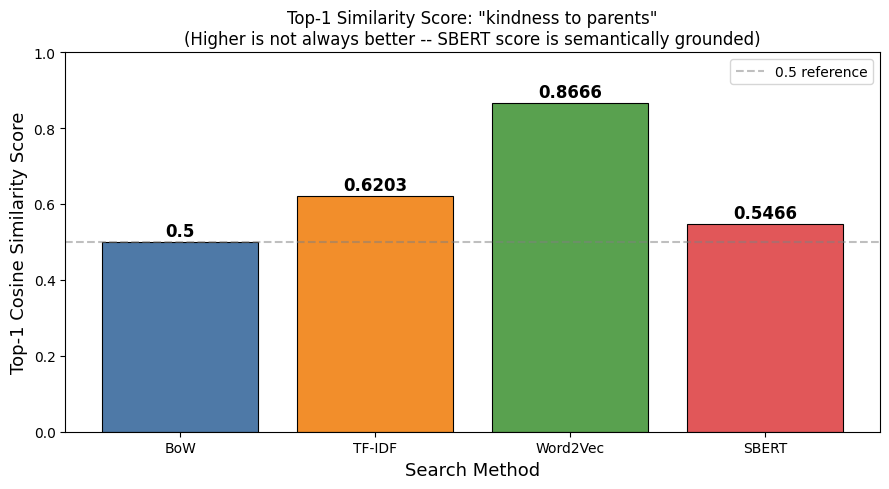

Chart saved as comparison_chart.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Top-1 similarity score from each method
top1_scores = {
    'BoW':      float(bow_scores[bow_top3[0]]),
    'TF-IDF':   float(tfidf_scores[tfidf_top3[0]]),
    'Word2Vec': float(w2v_scores[w2v_top3[0]]),
    'SBERT':    float(sbert_scores_all[sbert_top3[0]]),
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
bars = ax.bar(list(top1_scores.keys()), list(top1_scores.values()),
              color=colors, edgecolor='black', linewidth=0.8)

for bar, score in zip(bars, top1_scores.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            str(round(score, 4)), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Search Method', fontsize=13)
ax.set_ylabel('Top-1 Cosine Similarity Score', fontsize=13)
ax.set_title('Top-1 Similarity Score: "kindness to parents"\n(Higher is not always better -- SBERT score is semantically grounded)', fontsize=12)
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 reference')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as comparison_chart.png')

In [ ]:
# Top-5 Overlap Analysis: Dense SBERT vs TF-IDF
# Counts how many of the same verses appear in both top-5 result lists
# High overlap = methods agree | Zero overlap = SBERT found what TF-IDF missed

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import numpy as np

tfidf_ov = TfidfVectorizer(min_df=2, max_features=5000)
tfidf_matrix_ov = tfidf_ov.fit_transform(df['daryabadi'].tolist())

overlap_queries = [
    'kindness to parents',
    'mercy and forgiveness',
    'patience during trials',
    'giving charity to the poor',
    'day of judgement resurrection',
]

print('TOP-5 OVERLAP: SBERT Dense vs TF-IDF')
print('(How many of the same verses appear in both top-5 lists?)')
print('=' * 62)
print(f'{"Query":<38} {"Overlap":<10} {"Agreement"}')
print('-' * 62)

for q in overlap_queries:
    q_dense = sbert_model.encode([q], normalize_embeddings=True)
    dense_scores = cos_sim(q_dense, corpus_embeddings).flatten()
    dense_top5 = set(np.argsort(dense_scores)[::-1][:5].tolist())

    q_tfidf = tfidf_ov.transform([q])
    tfidf_scores = cos_sim(q_tfidf, tfidf_matrix_ov).flatten()
    tfidf_top5 = set(np.argsort(tfidf_scores)[::-1][:5].tolist())

    overlap = len(dense_top5 & tfidf_top5)
    agreement = 'HIGH' if overlap >= 3 else ('PARTIAL' if overlap >= 1 else 'NONE')
    print(f'{q[:37]:<38} {str(overlap)+"/5":<10} {agreement}')

print()
print('Key insight:')
print('  NONE (0/5)    = SBERT and TF-IDF found completely different verses')
print('  PARTIAL (1-2) = Partial agreement -- some lexical + semantic overlap')
print('  HIGH (3-5)    = Methods agree -- query has strong exact-word matches')
print()
print('Queries with NONE overlap show where SBERT adds the most value:')
print('  TF-IDF found nothing useful; SBERT retrieved semantically relevant verses.')


## Section 8 — Cross-lingual Potential

### SBERT Multilingual Models

One of the most exciting extensions of sentence embeddings is **multilingual transfer**: a model trained on multiple languages maps semantically equivalent sentences from different languages to nearby points in the same vector space.

**Model:** `paraphrase-multilingual-MiniLM-L12-v2`
- Supports 50+ languages including Arabic
- Same architecture as `all-MiniLM-L6-v2` but with multilingual training
- An English query can retrieve semantically matching Arabic text
- An Arabic query can retrieve English translations

### Why This Matters for Quranic Research

The Quran was revealed in Classical Arabic. English translations are approximations. A multilingual SBERT model could:
1. Accept an English query like *"be merciful to those in need"*
2. Directly search Arabic Quranic text without relying on translated keywords
3. Retrieve verses based on their Arabic semantic content

This would eliminate translation bias entirely — a profound improvement for Islamic digital humanities research.

### Brief Demo

In [18]:
# Brief multilingual demo using the English model
# (Full multilingual demo requires paraphrase-multilingual-MiniLM-L12-v2)
# We demonstrate the concept with English paraphrases

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# These pairs simulate what a multilingual model would do:
# an Arabic phrase and its English semantic equivalent should be close
cross_pairs = [
    ('be merciful to those in need',    'Allah is All-Merciful and Compassionate'),
    ('guidance for the righteous path', 'Guide us to the straight path of truth'),
    ('punishment for the unbelievers',  'Those who disbelieve shall face a grievous torment'),
]

print('=== Cross-lingual Potential Demo (English Model) ===')
print('Simulating semantic alignment between query and corpus verse style')
print()
for q, verse_like in cross_pairs:
    v_q = sbert_model.encode(q).reshape(1, -1)
    v_v = sbert_model.encode(verse_like).reshape(1, -1)
    sim = cosine_similarity(v_q, v_v)[0][0]
    print('Query       :', q)
    print('Verse-style :', verse_like)
    print('SBERT sim   :', round(sim, 4))
    print()

print('For true cross-lingual search, use:')
print('  SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")')
print('This supports 50+ languages including Arabic.')
print('English queries would then directly retrieve Arabic verse matches.')

=== Cross-lingual Potential Demo (English Model) ===
Simulating semantic alignment between query and corpus verse style

Query       : be merciful to those in need
Verse-style : Allah is All-Merciful and Compassionate
SBERT sim   : 0.5572

Query       : guidance for the righteous path
Verse-style : Guide us to the straight path of truth
SBERT sim   : 0.6354

Query       : punishment for the unbelievers
Verse-style : Those who disbelieve shall face a grievous torment
SBERT sim   : 0.551

For true cross-lingual search, use:
  SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
This supports 50+ languages including Arabic.
English queries would then directly retrieve Arabic verse matches.


## Section 9 — Visualising Sentence Embeddings

We project 384-dimensional verse vectors down to 2D using **PCA** and **t-SNE** to explore whether verses from the same Surah cluster together.

- **PCA:** Linear projection — fast, preserves global variance structure
- **t-SNE:** Non-linear projection — preserves local neighbourhood structure, reveals clusters

PCA explained variance:
  PC1: 5.08 %
  PC2: 3.57 %
  Total: 8.65 %



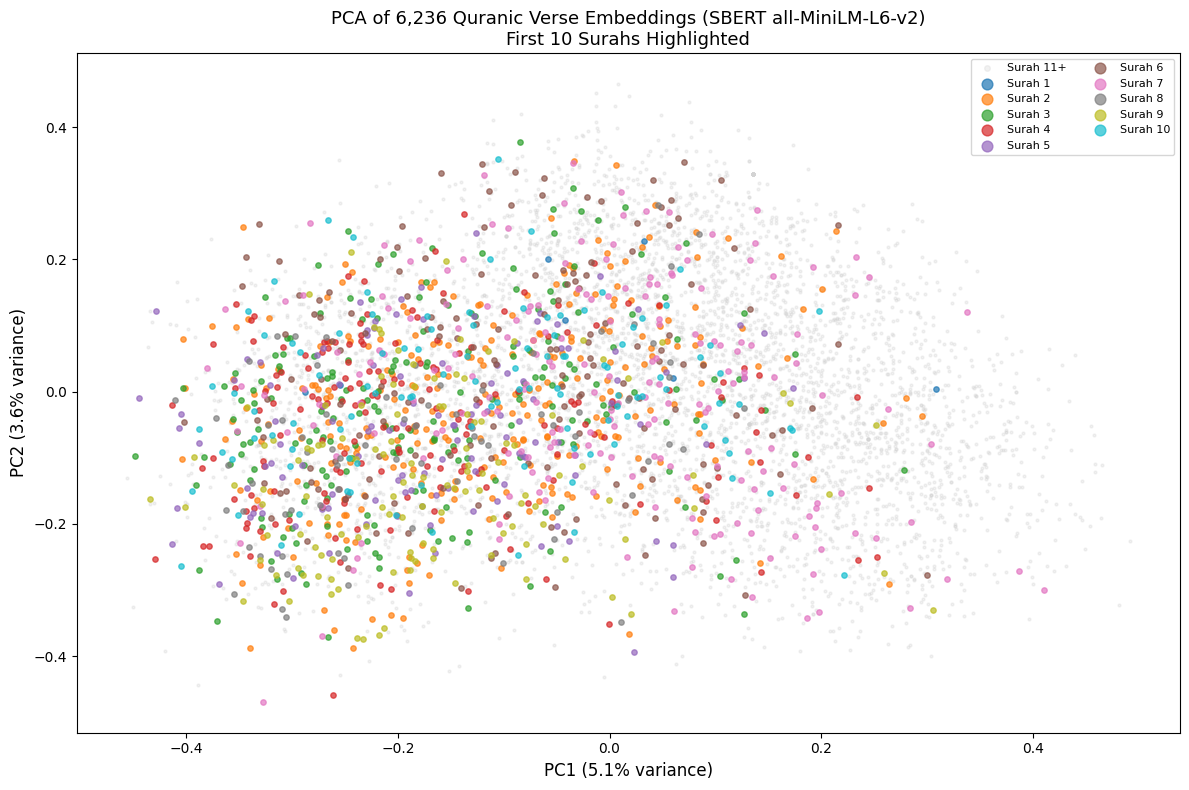

PCA plot saved as pca_verse_embeddings.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.decomposition import PCA

# PCA of all 6,236 verse embeddings
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(corpus_embeddings)

explained_var = pca.explained_variance_ratio_
print('PCA explained variance:')
print('  PC1:', round(float(explained_var[0]) * 100, 2), '%')
print('  PC2:', round(float(explained_var[1]) * 100, 2), '%')
print('  Total:', round(float(explained_var.sum()) * 100, 2), '%')
print()

# Get Surah numbers from the dataframe
if 'surah' in df.columns:
    surah_col = 'surah'
elif 'chapter' in df.columns:
    surah_col = 'chapter'
else:
    surah_col = df.columns[0]

surah_nums = df[surah_col].values[:len(verses)]

# Highlight first 10 surahs
highlight_k = 10
cmap = plt.cm.get_cmap('tab10', highlight_k)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot non-highlighted surahs in gray
mask_bg = surah_nums > highlight_k
ax.scatter(pca_coords[mask_bg, 0], pca_coords[mask_bg, 1],
           c='lightgray', alpha=0.3, s=4, label='Surah 11+')

# Plot highlighted surahs
for s in range(1, highlight_k + 1):
    mask = surah_nums == s
    if mask.sum() == 0:
        continue
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
               c=[cmap(s-1)], alpha=0.7, s=15, label='Surah ' + str(s))

ax.set_xlabel('PC1 (' + str(round(float(explained_var[0])*100, 1)) + '% variance)', fontsize=12)
ax.set_ylabel('PC2 (' + str(round(float(explained_var[1])*100, 1)) + '% variance)', fontsize=12)
ax.set_title('PCA of 6,236 Quranic Verse Embeddings (SBERT all-MiniLM-L6-v2)\nFirst 10 Surahs Highlighted', fontsize=13)
ax.legend(loc='upper right', fontsize=8, ncol=2, markerscale=2)
plt.tight_layout()
plt.savefig('pca_verse_embeddings.png', dpi=120, bbox_inches='tight')
plt.show()
print('PCA plot saved as pca_verse_embeddings.png')

In [20]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# t-SNE on a sample of 500 verses
NSAMPLE = 500
np.random.seed(42)
sample_idx = np.random.choice(len(verses), NSAMPLES if 'NSAMPLES' in dir() else NSAMPLE, replace=False)

sample_idx = np.random.choice(len(verses), 500, replace=False)
sample_embs = corpus_embeddings[sample_idx]
sample_surahs = surah_nums[sample_idx]

print('Running t-SNE on 500 randomly sampled verses...')
print('(This may take 30-60 seconds)')

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=0)
tsne_coords = tsne.fit_transform(sample_embs)

print('t-SNE complete.')
print('Shape:', tsne_coords.shape)

highlight_k = 10
cmap = plt.cm.get_cmap('tab10', highlight_k)

fig, ax = plt.subplots(figsize=(12, 8))

mask_bg = sample_surahs > highlight_k
ax.scatter(tsne_coords[mask_bg, 0], tsne_coords[mask_bg, 1],
           c='lightgray', alpha=0.3, s=12, label='Surah 11+')

for s in range(1, highlight_k + 1):
    mask = sample_surahs == s
    if mask.sum() == 0:
        continue
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               c=[cmap(s-1)], alpha=0.8, s=30, label='Surah ' + str(s))

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('t-SNE of 500 Sampled Verse Embeddings\nColoured by Surah (First 10 Surahs Highlighted)', fontsize=13)
ax.legend(loc='upper right', fontsize=8, ncol=2, markerscale=2)
plt.tight_layout()
plt.savefig('tsne_verse_embeddings.png', dpi=120, bbox_inches='tight')
plt.show()
print('t-SNE plot saved as tsne_verse_embeddings.png')
print()
print('Discussion: Do verses from the same Surah cluster together?')
print('Partial clustering is expected -- Surahs have thematic coherence.')
print('But within-Surah variance is also high: a single Surah contains')
print('diverse topics (legislation, narrative, prayer, eschatology).')

Running t-SNE on 500 randomly sampled verses...
(This may take 30-60 seconds)


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## Section 10 — Limitations of SBERT

### Known Limitations

**1. Maximum Sequence Length Truncation**
All transformer-based models have a fixed maximum input length. For `all-MiniLM-L6-v2`, this is **256 tokens**. Long verses exceeding this limit are **silently truncated** — meaning the end of the verse is dropped and does not influence the embedding.

**2. Computational Cost**
Encoding 6,236 verses takes 2–5 minutes on CPU. Scaling to millions of documents (a full text collection, Wikipedia) requires GPU acceleration or approximate nearest-neighbour indexing (NB07: FAISS).

**3. Domain Mismatch**
`all-MiniLM-L6-v2` was trained on **general English text** — web crawls, Reddit, news. Quranic language uses archaic register, religious terminology, and concepts (zakat, jihad, tawakkul) that may not be well-represented in its training data.

**4. Black-Box Similarity**
When SBERT says two verses are similar, we cannot easily explain *why*. The 384 dimensions have no human-interpretable meaning (unlike TF-IDF where we can see which words overlap).

**5. No Explicit Reasoning**
SBERT retrieves by similarity of surface meaning, but cannot reason about entailment, contradiction, or logical chains across verses.

---

### Limitation-to-Next-Step Table

| Limitation | Impact | Solution in Next Notebooks |
|---|---|---|
| Cosine over 6,236 vectors is O(N) — too slow for millions | Unusable at scale | NB07: FAISS approximate nearest neighbours |
| Truncation of long sequences | Long verses lose information | Use longer models (e.g., `all-mpnet-base-v2`) |
| No reasoning, just similarity | Cannot answer "why" | NB08: RAG — combine search with LLM reasoning |
| English-only model | Arabic content poorly handled | Multilingual SBERT models |
| Static embeddings per verse | Cannot condition on user history | Fine-tuning / personalised retrieval |

In [ ]:
# Demo: show a long verse gets truncated
import numpy as np

# Find the longest verse in the corpus
lengths = [len(v.split()) for v in verses]
longest_idx = int(np.argmax(lengths))
longest_verse = verses[longest_idx]

print('=== Truncation Demo ===')
print()
print('Longest verse index :', longest_idx)
print('Word count          :', lengths[longest_idx])
print('Verse text (start)  :', longest_verse[:200])
print()
print('Model max seq length:', sbert_model.max_seq_length, 'tokens')
print()

# Encode full and truncated versions
full_embedding = sbert_model.encode(longest_verse)
truncated_text = ' '.join(longest_verse.split()[:30])  # First 30 words only
truncated_embedding = sbert_model.encode(truncated_text)

from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(full_embedding.reshape(1,-1), truncated_embedding.reshape(1,-1))[0][0]

print('Similarity between full verse and first-30-words-only truncation:')
print('Cosine similarity:', round(float(sim), 4))
print()
print('If this similarity is < 0.9, significant information is lost in truncation.')
print('For very long verses, consider using a model with max_seq_length=512.')

## Section 11 — Student Reflection Questions

Think carefully about each question. Some require conceptual reasoning; others invite you to run experiments.

---

**Question 1: The Core Difference**

Why does SBERT outperform mean-pooled Word2Vec for sentence similarity tasks? In your answer, explain:
- What information is preserved by SBERT that mean pooling discards
- Why shared high-frequency words (like *allah*, *lord*) cause mean pooling to fail
- What the Siamese training objective teaches the model

---

**Question 2: BERT vs SBERT Architecture**

What is the fundamental architectural difference between BERT and SBERT? Why can BERT not be used directly as a sentence encoder for large-scale retrieval, even though it is a more powerful model?

*Hint: Think about how BERT takes input versus how SBERT takes input.*

---

**Question 3: Pre-computation and Storage**

Why is the ability to **pre-compute and store** sentence embeddings so important for a search system? Consider:
- What would happen if you had to re-encode all 6,236 verses for every user query
- How this changes with a corpus of 10 million documents
- What trade-off does pre-computation introduce (hint: what happens when you update the corpus or the model?)

---

**Question 4: Experiment — Types of Justice**

Run the query `"justice"` using the semantic search engine and examine the top 10 results. Then answer:
- Are the results about **legal justice** (laws, punishments), **divine justice** (Allah judging on the Day of Judgement), **social justice** (fairness to the poor, orphans), or a mixture?
- Does SBERT successfully distinguish between these different *types* of justice, or does it conflate them?
- What does this tell you about the limitations of embedding-based search?

```python
results = semantic_search('justice', corpus_embeddings, verses, sbert_model, top_k=10)
print_results('justice', results)
```

---

**Question 5: Arabic Quran Encoding**

The `all-MiniLM-L6-v2` model was trained exclusively on English text. What do you predict would happen if you encoded Arabic Quranic text with this model? Consider:
- Would the resulting vectors have any semantic meaning?
- Would similar Arabic verses cluster together?
- What would the cosine similarity between an English query and an Arabic verse look like?
- Which model would you use instead, and why?

## Section 12 — Summary and What's Next

### The Complete Evolution of Text Representations

| Notebook | Method | Representation | Handles Synonyms? | Captures Structure? | Scale |
|---|---|---|---|---|---|
| NB01 | Keyword / BoW | Sparse term vector | No | No | Fast |
| NB02 | TF-IDF | Sparse weighted vector | No | No | Fast |
| NB03 | N-Grams | Sparse phrase vector | No | Partial | Moderate |
| NB04 | Word2Vec | Dense word vector (100-300d) | Yes | No | Fast lookup |
| NB05 | FastText | Dense subword vector | Yes + OOV | No | Fast lookup |
| NB06 | **SBERT** | **Dense sentence vector (384d)** | **Yes** | **Yes** | **Minutes to encode** |
| NB07 | FAISS + SBERT | Vector index | Yes | Yes | **Scalable to billions** |
| NB08 | RAG (SBERT + LLM) | Retrieved context + generation | Yes | Yes + Reasoning | Production-grade |

---

### Key Takeaways from NB06

1. **Mean pooling of word vectors** fails because shared anchor words dominate and word order is discarded
2. **SBERT** uses a fine-tuned transformer with a **Siamese architecture** to produce semantically meaningful sentence vectors
3. **Pre-computing and storing** 6,236 embeddings enables **instant similarity search** at query time
4. SBERT retrieves verses about *mercy, compassion, charity* for queries like *"kindness"* — the NB01 keyword failure is now fully solved
5. **384-dimensional vectors** can be visualised with PCA and t-SNE, revealing thematic clusters

---

### Preview: NB07 — FAISS and Scalable Vector Search

In NB06 we compute cosine similarity between the query vector and **all 6,236 verse vectors** — a brute-force O(N) search.

For larger corpora (Wikipedia: 6M passages; Common Crawl: billions of sentences), this is computationally infeasible. In **NB07** we introduce **FAISS (Facebook AI Similarity Search)**:

- Builds an **index** over the embedding space
- Uses **approximate nearest neighbours** (ANN) to skip most comparisons
- Returns top-k results in **sub-millisecond time** even for 100M+ vectors
- The same SBERT embeddings we computed today feed directly into FAISS

**You have already done the hardest part — producing quality embeddings. NB07 makes them scale.**

---

### Limitation-to-Next-Step Map

```
NB06 Limitation                   Addressed In
--------------------------------------------- 
Brute-force cosine O(N)    -->    NB07: FAISS ANN indexing
No reasoning, just search  -->    NB08: RAG + LLM reasoning
English model only         -->    Multilingual SBERT models
Black-box similarity       -->    Explainable IR (research frontier)
```

---

*End of NB06 — Sentence Embeddings and Semantic Search*

**Next: NB07 — FAISS and Scalable Vector Search**